<a href="https://colab.research.google.com/github/tashir0605/Cocepts-And-Practice/blob/main/Capstone%20Project/Youtube_Comment_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv")
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [5]:
df.shape

(37249, 2)

In [6]:
df.describe

<bound method NDFrame.describe of                                            clean_comment  category
0       family mormon have never tried explain them t...         1
1      buddhism has very much lot compatible with chr...         1
2      seriously don say thing first all they won get...        -1
3      what you have learned yours and only yours wha...         0
4      for your own benefit you may want read living ...         1
...                                                  ...       ...
37244                                              jesus         0
37245  kya bhai pure saal chutiya banaya modi aur jab...         1
37246              downvote karna tha par upvote hogaya          0
37247                                         haha nice          1
37248             facebook itself now working bjp’ cell          0

[37249 rows x 2 columns]>

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [8]:
df.isnull().sum() # to check any missing value

,0
clean_comment,100
category,0


We have 100 values missing in the clean Comment

In [9]:
df[df['clean_comment'].isna()]  # to see the rows of clean comment where values are missing

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [10]:
df.dropna(inplace=True)  # to drop

In [11]:
df.duplicated().sum()

np.int64(350)

In [12]:
df[df['clean_comment'].duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(36799, 2)

In [15]:
df[(df['clean_comment'].str.strip()=='')]  # to check where the clean comment column is empty

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [16]:
df=df[~(df['clean_comment'].str.strip()=='')] # remove with the help of negation

In [17]:
df.shape

(36793, 2)

In [18]:
df['clean_comment']=df['clean_comment'].str.lower()

/tmp/ipykernel_22914/980075517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment']=df['clean_comment'].str.lower()


In [19]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [20]:
# Remove trailing and leading whitespaces from the 'clean_comment' column
df['clean_comment']=df['clean_comment'].str.strip()

/tmp/ipykernel_22914/864462942.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment']=df['clean_comment'].str.strip()


In [21]:
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [22]:
url_pattern=r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
# Display the comments with containing URLs
df[df['clean_comment'].str.contains(url_pattern)]

,clean_comment,category


In [23]:
#Identify the comments containing new line characers

comments_with_newlines=df[df['clean_comment'].str.contains('\n')]
print(comments_with_newlines)

                                           clean_comment  category
448    what missing jpg\nand why this brilliant edit ...         1
781    india has been ruined congress and populist sc...        -1
847    like aap for its stand corruption and making p...        -1
871    reduced trade\ndeficit stronger rupee aren the...         0
1354   amsa press conference australian maritime safe...         1
...                                                  ...       ...
35128  火箭o辛基 2016 sughosh bansal mission “make india”...        -1
35230  yikes the title should blind bhakts modi hater...         1
36187                 hahahahahhahahah \niska klpd hogya         0
36517                         ्ा् ी ाी े ो ेी ाी े।\nे ी         0
36919  y6sg1xuovbb0czfwjpug0h html\nfull credit anti ...         1

[204 rows x 2 columns]


In [24]:
#Remove new line charatcer from the "clean commnet" and replace it with whitespace

df['clean_comment']=df['clean_comment'].str.replace('\n',' ', regex=True)

/tmp/ipykernel_22914/3938325294.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment']=df['clean_comment'].str.replace('\n',' ', regex=True)


# EDA

<Axes: xlabel='category', ylabel='count'>

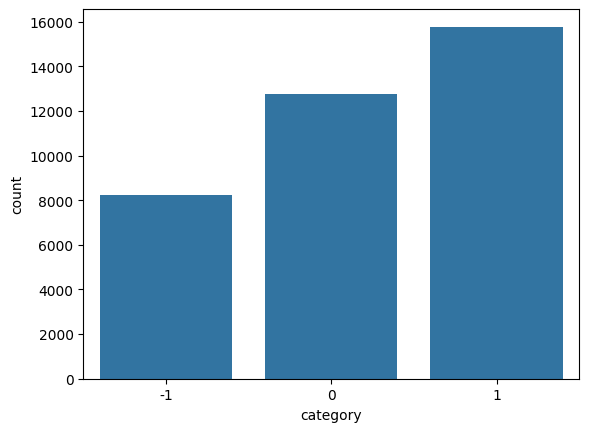

In [25]:
 import seaborn as sns
 import matplotlib.pyplot as plt

 sns.countplot(data=df, x="category")

In [26]:
df['category'].value_counts(normalize=True).mul(100).round(2)  # justb to see the distribution of the Sentiments

,proportion
category,
1,42.86
0,34.71
-1,22.42


Observing the Word_Count

In [27]:
#Added a new column to the df that is wordcount
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))

/tmp/ipykernel_22914/1445293433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))


In [28]:
df.sample(5)

,clean_comment,category,word_count
31159,just modiji looking bit different,0,5
11924,best week history,1,3
3933,fuckkk huzzzah bjp supporter and still happy t...,1,27
34024,man want that sony amp bad how much did that c...,-1,18
3160,bjp throws garbage indian islamic cultural cen...,1,16


In [29]:
df['clean_comment'][17127]

'can tell nazi mod'

By seeing the description of the WordCount, I can conclude that
*  Mean is 29.6 and std is 56.79 suggests the data is not clustered tightly around the center.
*  it means the data is Skewed.
* Moreover the max count is 1307 that is very huge



In [30]:
df['word_count'].describe()

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


By seeing the Graph we can clearly say that, bhut kam comments aise hai jahan pe jyada number of words use hue hai and bhut jyada commnets hai jahan pe bhut km number of words use hue hai

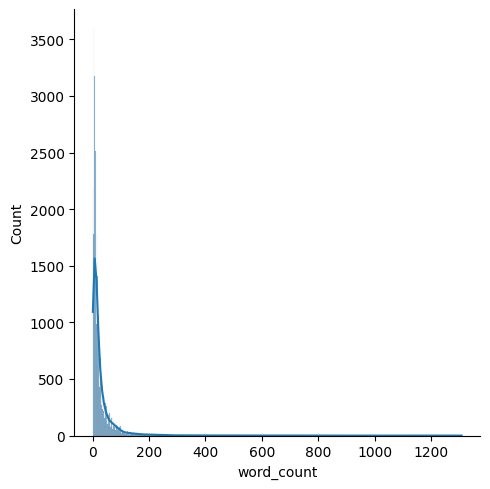

In [31]:
import seaborn as sns
sns.displot(df['word_count'],kde=True)

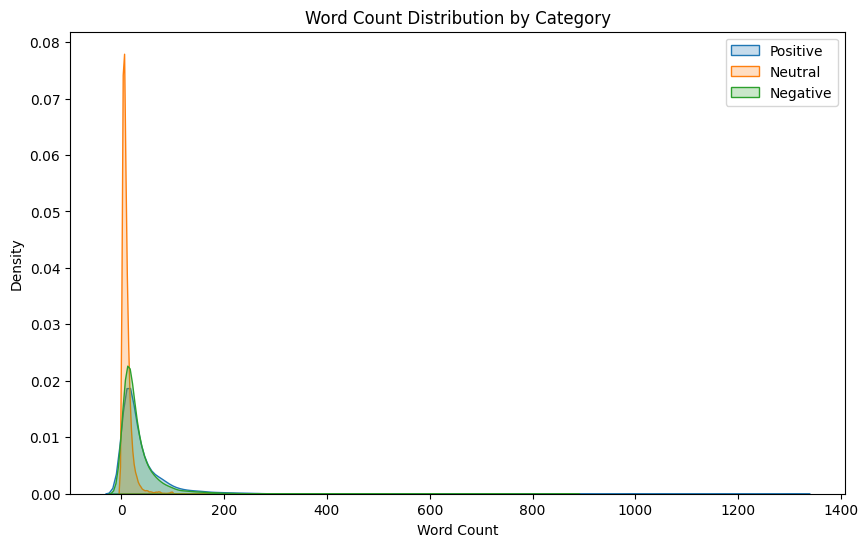

In [32]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# Add a legend
plt.legend()

**Positive comments (category 1):** These tend to have a wider spread in word count, indicating that longer comments are more common in positive sentiments.

**Neutral comments (category 0):** The distribution shows a relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.

**Negative comments (category -1):** These comments have a distribution somewhat similar to positive comments but with a smaller proportion of longer comments.

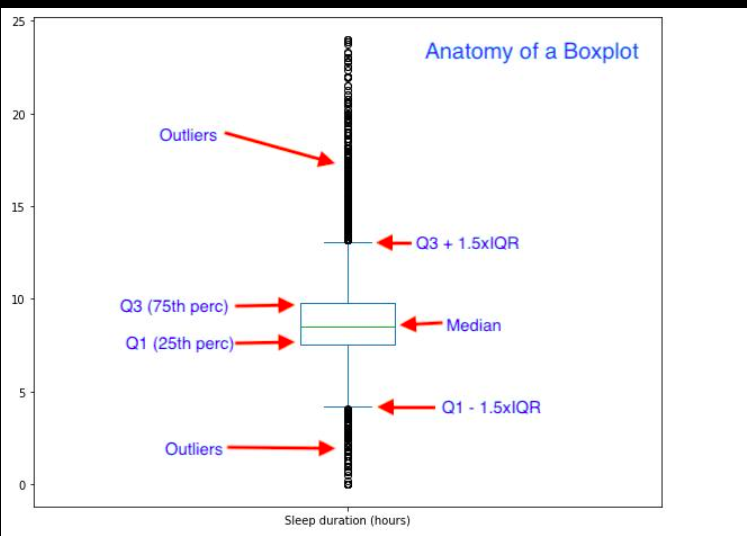

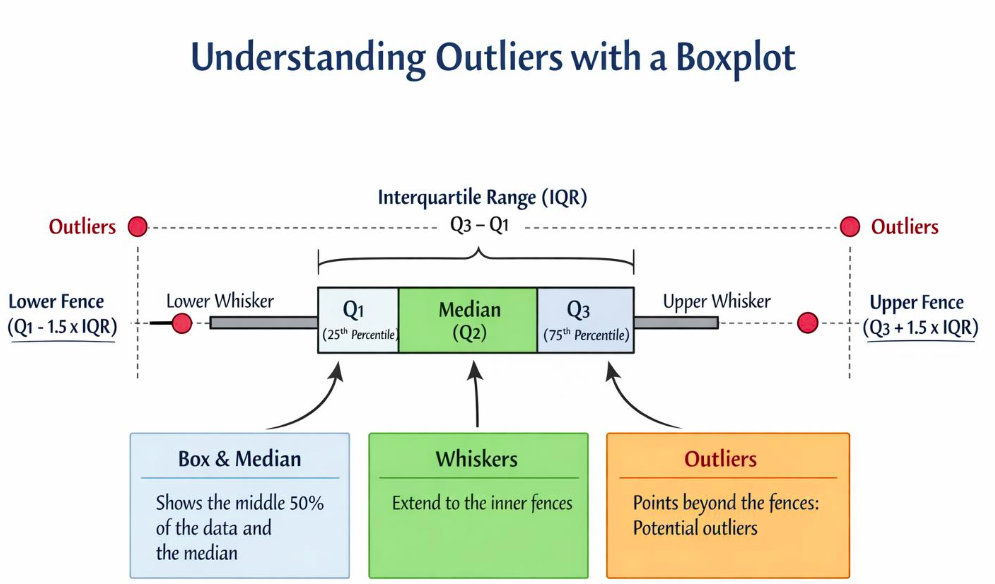

<Axes: ylabel='word_count'>

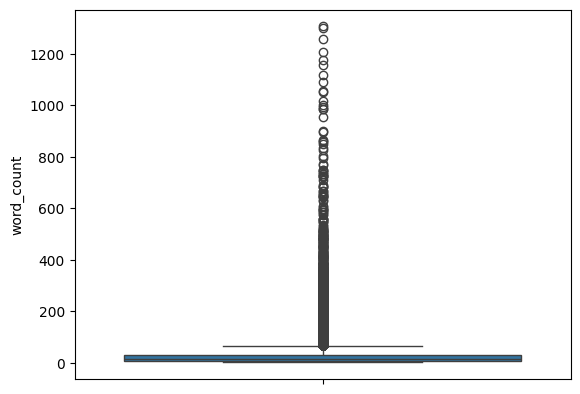

In [33]:
sns.boxplot(df['word_count'])

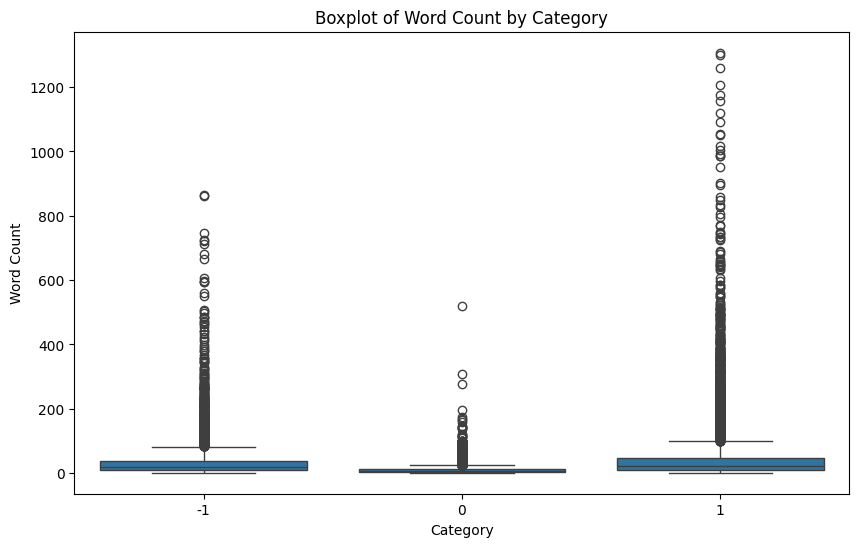

In [34]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Positive comments (category 1)**: The median word count is relatively high, and there are several outliers with longer comments, indicating that positive comments tend to be more verbose.


**Neutral comments (category 0)**: The median word count is the lowest, with a tighter interquartile range (IQR), suggesting that neutral comments are generally shorter.


**Negative comments (category-1)**: The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers.

* Most texts are short
* Few texts are extremely long

<Axes: xlabel='category', ylabel='word_count'>

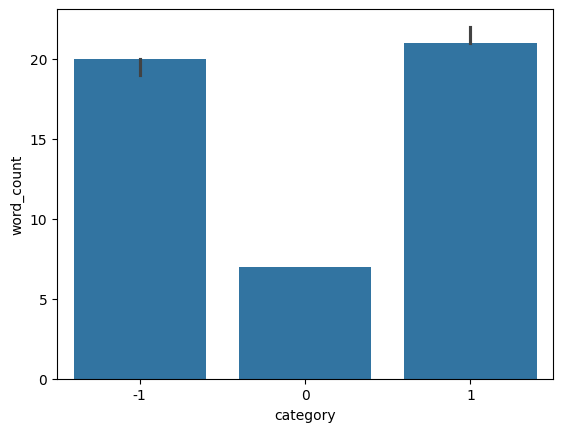

In [35]:
sns.barplot(df,x='category',y='word_count', estimator='median')

In nutshell if we have to say, the neutral comments show different behaviour than those of Positive commnet

In [36]:
!pip install nltk

In [37]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

# Define the list of English stopwords
stop_words = set(stopwords.words('english'))

# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipykernel_22914/346845087.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))


In [38]:
df.sample(6)

,clean_comment,category,word_count,num_stop_words
5788,the article talks about there being increase c...,-1,40,16
32417,this from actual newspaper,0,4,2
19433,pandey nahi pandey,0,3,0
24807,monthly labour wages have fallen any source fo...,-1,47,14
33389,god what clusterfuck what you think will the f...,0,11,5
14155,sorry for the very fake news source media,-1,8,3


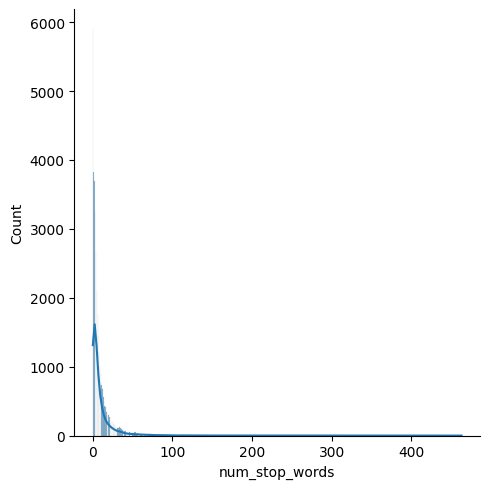

In [39]:
sns.displot(df['num_stop_words'],kde=True)

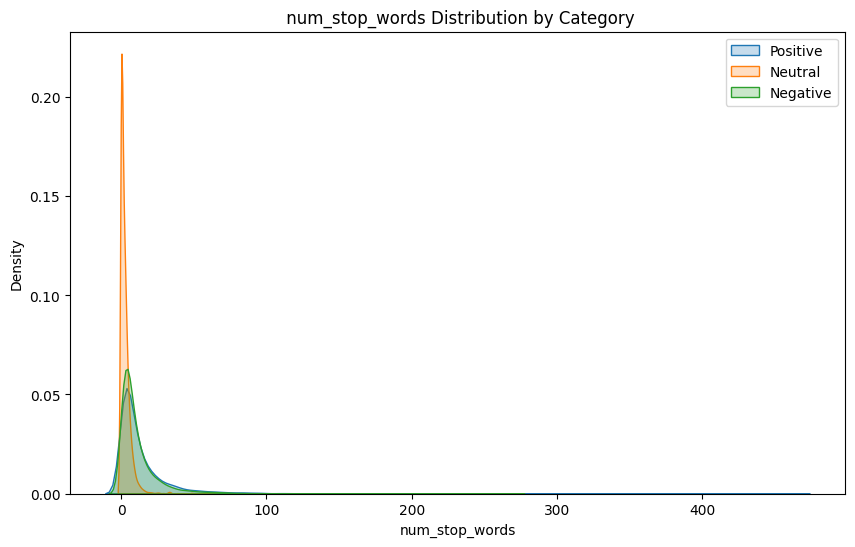

In [41]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

# Add title and labels
plt.title(' num_stop_words Distribution by Category')
plt.xlabel('num_stop_words')
plt.ylabel('Density')

# Add a legend
plt.legend()

<Axes: xlabel='category', ylabel='num_stop_words'>

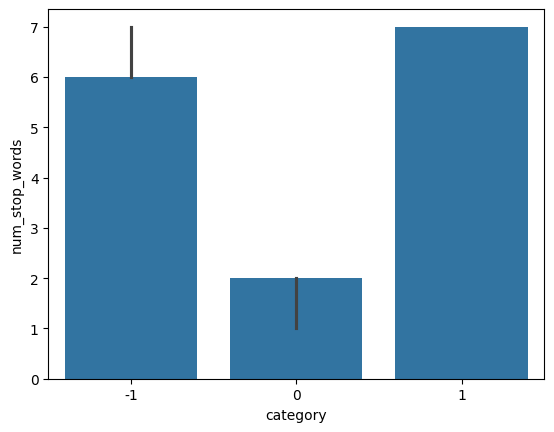

In [42]:
sns.barplot(df,x='category',y='num_stop_words', estimator='median')

/tmp/ipykernel_22914/87103404.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


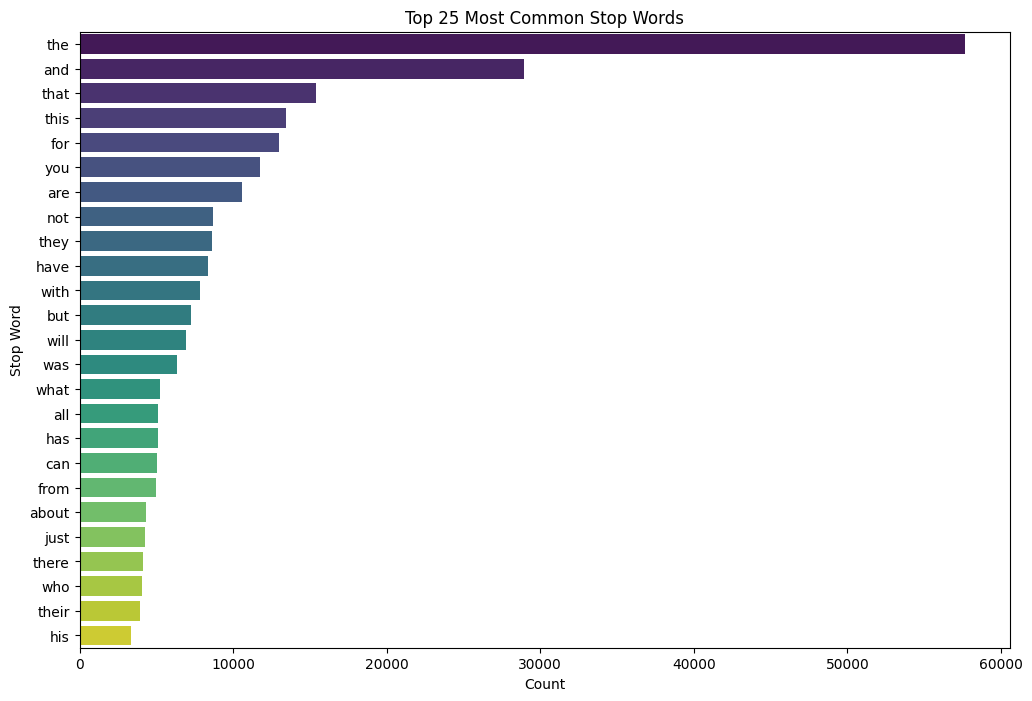

In [43]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

As we can see not, but are kind of words that are critical for sentiment Analysis. So we have to Handle this carefully

In [45]:
df['num_chars']=df['clean_comment'].apply(len)
df.head()

/tmp/ipykernel_22914/813794760.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_chars']=df['clean_comment'].apply(len)


,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [47]:
df['num_chars'].describe()

,num_chars
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


In [49]:
from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

In [50]:
char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
...,...,...
1345,唯,1
1346,统,1
1330,段,1
1331,她,1


As we can see there are various characters in the data that are non English that should be treated

In [ ]:
import string

# Create a new column 'num_punctuation_chars' to count the punctution characters in each comments

df.loc[:, 'num_punctuation_chars'] = df['clean_comment'].apply(lambda x: len([char for char in x if char in string.punctuation]))

In [54]:
df.sample(6)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
35246,lol that god level trolling bjp,1,6,1,31,0
30754,such defensive much moron,-1,4,1,25,0
20446,this what should have been done earlier not pr...,0,16,8,99,0
2968,like this new indian kinda cool lets hope work...,1,20,6,118,0
18444,thanks for the same guy calls very honest expe...,1,26,10,146,0
24405,kind liberal terms trade economy and free mark...,1,74,27,493,0


After doing num_punctuation_chars I see ki there are no Punctuation mark in the data.

* it can have positive as well negative impact. As punctuation marks like !, !! , ? tells us about the sentiment of the text that we are writing.

/tmp/ipykernel_22914/2646790824.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


Text(0, 0.5, 'Bigram')

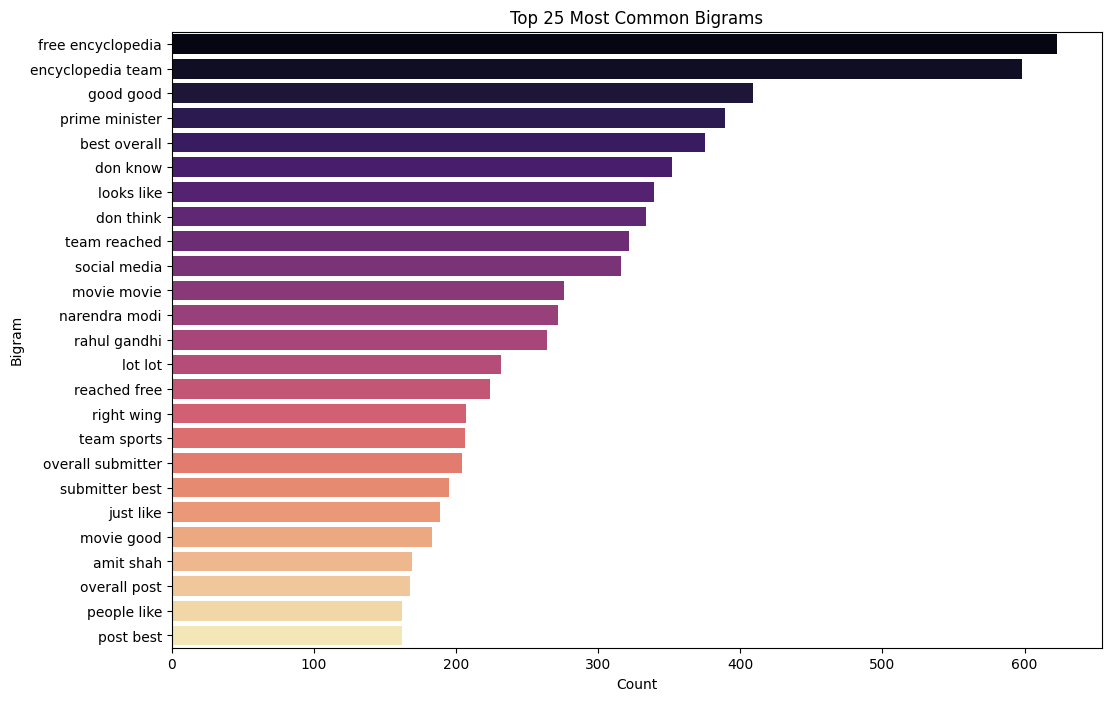

In [55]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')

/tmp/ipykernel_22914/3807244167.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='viridis')


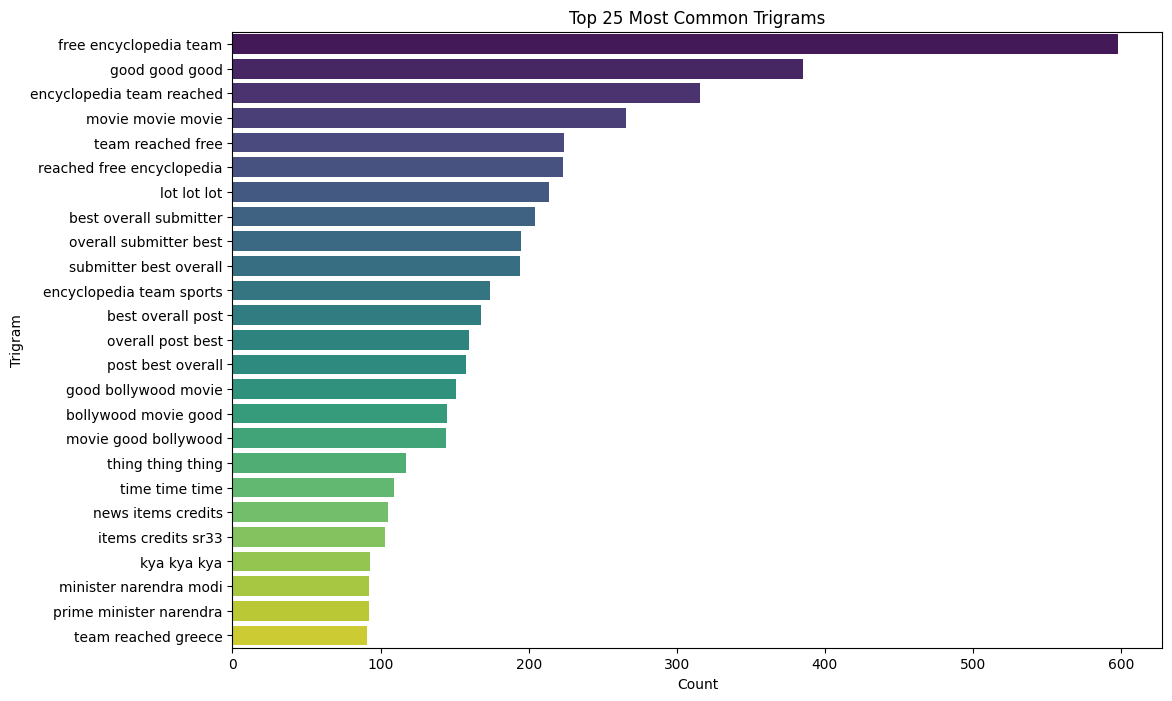

In [56]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='viridis')

plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [57]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation

import re

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: re.sub(r'[^A-Za-z0-9\s!?,.]', '', str(x))
)

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

/tmp/ipykernel_22914/3971067785.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment'] = df['clean_comment'].apply(


In [58]:
char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [59]:
# Remove stopwords from the 'clean_comment' column

import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))-{'not','but','however', 'no', 'yet'}

# Remove stopwords and replace those stopwords with space
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join(
        [word for word in str(x).split() if word.lower() not in stop_words]
    )
)

# Display sample output
df['clean_comment'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_22914/3957479002.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment'] = df['clean_comment'].apply(


,clean_comment
0,family mormon never tried explain still stare ...
1,buddhism much lot compatible christianity espe...
2,seriously say thing first get complex explain ...
3,learned want teach different focus goal not wr...
4,benefit may want read living buddha living chr...


In [62]:
# Perform Lemmatization on the 'clean_comment' column

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required resources (run once)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Added to resolve LookupError

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df.loc[:, 'clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join(
        [lemmatizer.lemmatize(word) for word in word_tokenize(str(x))]
    )
)

# Display sample output
df['clean_comment'].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,clean_comment
0,family mormon never tried explain still stare ...
1,buddhism much lot compatible christianity espe...
2,seriously say thing first get complex explain ...
3,learned want teach different focus goal not wr...
4,benefit may want read living buddha living chr...


In [64]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""

    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))

    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')

    plt.show()